# Freight Rate Prediction — Data Exploration

## Objective

This notebook explores and audits the development dataset provided for the
Freight Rate Prediction challenge.

The main objectives are to:

- Understand the structure and characteristics of the data.
- Identify data-quality issues and potential anomalies.
- Analyze the target variable and its relationship with available features.
- Investigate temporal, geographic, categorical, and numerical patterns.
- Identify potential data leakage risks.
- Generate evidence-based insights to guide feature engineering,
  validation strategy, and model selection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
DATA_PATH="../data/train-test.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [3]:
df.shape

(48000, 14)

### Insight

The development dataset contains 48,000 loads and 14 columns. This provides a substantial number of observations for exploratory analysis, model development, and validation.

The dataset includes both operational load attributes and market-related signals, with `posted_rate` serving as the prediction target.

In [4]:
df.columns.tolist()

['load_id',
 'pickup',
 'delivery',
 'pickup_lat',
 'pickup_lon',
 'delivery_lat',
 'delivery_lon',
 'distance',
 'equipment',
 'weight',
 'date',
 'market_index',
 'quote_signal',
 'posted_rate']

In [5]:
df.dtypes

load_id          object
pickup           object
delivery         object
pickup_lat      float64
pickup_lon      float64
delivery_lat    float64
delivery_lon    float64
distance        float64
equipment        object
weight          float64
date             object
market_index    float64
quote_signal    float64
posted_rate     float64
dtype: object

### Insight

The dataset contains a mix of categorical, numerical, and temporal fields.

Most numerical variables are already represented as `float64`, while categorical fields are stored as `object`. The `date` field is currently stored as `object` and will require datetime conversion before temporal analysis.

The target, `posted_rate`, is a continuous numerical variable, confirming that the prediction task is a regression problem.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


### Insight

The development dataset contains 48,000 observations and 14 columns.

The dataset is mostly complete, but two features contain missing values:
`weight` has 300 missing observations (0.625%), while `market_index`
has 374 missing observations (approximately 0.78%).

The target variable, `posted_rate`, has no missing values, which means
all development observations currently have an available target for
supervised regression evaluation.

The `date` column is currently stored as `object` and will require
datetime conversion before temporal analysis.

In [7]:
df.isna().sum()

load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64

### Insight

The dataset has missing values in only two features:

- `weight`: 300 missing values (0.625% of observations).
- `market_index`: 374 missing values (approximately 0.78% of observations).

All other columns are complete, including the target variable `posted_rate`.

The relatively small proportion of missing values means the missing-data problem is limited in scope, but the appropriate treatment will be determined later based on the feature distributions and modeling strategy.

In [8]:
df.duplicated().sum()

np.int64(0)

### Insight

No fully duplicated rows were found in the development dataset.

However, full-row duplication does not guarantee that `load_id` values are unique. Since `load_id` is expected to identify individual loads, its uniqueness will be checked separately.

In [9]:
df["load_id"].nunique()

48000

### Insight

All 48,000 observations have unique `load_id` values, matching the total number of rows in the dataset.

This confirms that `load_id` can be treated as a unique identifier for each load and should not be used as a predictive feature.

In [10]:
df[["pickup", "delivery" , "equipment"]].nunique()

pickup       64
delivery     64
equipment     3
dtype: int64

### Insight

The dataset contains 64 unique pickup locations, 64 unique delivery locations,
and 3 equipment categories.

The relatively limited number of categorical values makes these features
tractable for further exploratory analysis and encoding.

The actual category values and their frequencies will be inspected next to
identify rare categories, inconsistencies, or unexpected values.

In [11]:
df["equipment"].value_counts()

equipment
Dry Van    27202
Reefer     12045
Flatbed     8753
Name: count, dtype: int64

### Insight

The `equipment` feature contains three categories with a non-uniform distribution:

- `Dry Van`: 27,202 loads (56.67%)
- `Reefer`: 12,045 loads (25.09%)
- `Flatbed`: 8,753 loads (18.24%)

`Dry Van` is the dominant equipment category, while `Reefer` and `Flatbed`
still have substantial representation in the dataset.

No extremely rare equipment category was observed, so all three categories
can be retained for modeling.

In [12]:
df["pickup"].value_counts().head(10)

pickup
Oklahoma City    1242
Lexington        1209
Bakersfield      1193
Fort Wayne       1170
Hartford         1150
Richmond         1140
Nashville        1124
Phoenix          1121
Baton Rouge      1115
Mobile           1094
Name: count, dtype: int64

### Insight

The pickup locations are distributed across 64 unique locations.

The ten most frequent pickup locations each contribute roughly 1,094 to
1,242 loads, indicating that the dataset is not dominated by a single
pickup location.

A complete frequency distribution will be considered later when assessing
rare locations and their potential impact on categorical encoding.

In [13]:
df["delivery"].value_counts().head(10)

delivery
Lexington        1197
Fort Wayne       1176
Baton Rouge      1167
Bakersfield      1156
Hartford         1143
Oklahoma City    1140
Richmond         1109
Atlanta          1096
Phoenix          1090
Mobile           1089
Name: count, dtype: int64

### Insight

The delivery locations are also distributed across 64 unique locations.

The ten most frequent delivery locations contribute approximately 1,089 to
1,197 loads each, with no single location dominating the dataset based on
the top-10 frequency distribution.

The full category distribution should still be examined to identify any
rare delivery locations before deciding on the encoding strategy.

In [14]:
set(df["pickup"].unique()) == set(df["delivery"].unique())

True

### Insight

The set of unique pickup locations is identical to the set of unique
delivery locations: both contain the same 64 locations.

However, this does not imply that the frequency of each location is the
same for pickup and delivery. The frequency distributions should be
analyzed separately.

In [15]:
df.describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31028.844004,1.083387,2.062468,2373.980682
std,4.315285,13.482431,4.317199,13.476589,728.564416,9391.440620,0.168091,0.291391,1486.493245
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,0.676390,0.692280,57.220000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25800.000000,0.949670,1.891030,1251.555000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31436.500000,1.055800,2.055750,2030.760000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37018.000000,1.219590,2.221685,3330.750000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,1.467780,3.610350,25533.000000


In [16]:
(df["weight"] < 0).sum()

np.int64(292)

In [17]:
df.loc[df["weight"] < 0, "weight"].sort_values().head(20)

5034    -47500.0
5236    -47500.0
18488   -47500.0
26026   -47500.0
12591   -47500.0
13620   -47500.0
20576   -47500.0
18064   -47500.0
26106   -47500.0
16823   -47500.0
28877   -47500.0
34282   -47500.0
22422   -47500.0
6529    -46334.0
7987    -46187.0
10480   -45975.0
8384    -45588.0
40554   -45221.0
14562   -45128.0
30685   -44754.0
Name: weight, dtype: float64

In [18]:
df.loc[df["weight"] < 0, "weight"].value_counts().sort_index()

weight
-47500.0    13
-46334.0     1
-46187.0     1
-45975.0     1
-45588.0     1
            ..
-13852.0     1
-13119.0     1
-12836.0     1
-11574.0     1
-5000.0      1
Name: count, Length: 275, dtype: int64

### Insight

The `weight` feature contains 292 negative observations across 275 distinct
negative values.

The negative values are distributed across a range rather than being
represented by a single repeated value. The most frequent negative value,
`-47,500`, occurs 13 times.

These observations are treated as data-quality anomalies for further
investigation. No values are modified or removed at this stage.

In [19]:
(df["weight"] == 0).sum()

np.int64(0)

### Insight

The `weight` feature contains no zero-valued observations.

Across the 48,000 observations:
- 300 values are missing.
- 292 values are negative.
- 0 values are equal to zero.
- 47,408 observations have positive weights.

The negative values remain classified as data-quality anomalies and will be investigated before any preprocessing decision is made.

In [20]:
Q1 = df["weight"].quantile(0.25)
Q3 = df["weight"].quantile(0.75)

IQR = Q3 - Q1

Q1, Q3, IQR

(np.float64(25800.0), np.float64(37018.0), np.float64(11218.0))

In [21]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound

(np.float64(8973.0), np.float64(53845.0))

In [22]:
weight_outliers = df[
    (df["weight"] < lower_bound) |
    (df["weight"] > upper_bound)
]

len(weight_outliers)

424

In [23]:
negative_outliers = (df["weight"] < 0).sum()
positive_outliers = (
    (df["weight"] >= 0) &
    ((df["weight"] < lower_bound) | (df["weight"] > upper_bound))
).sum()

negative_outliers, positive_outliers

(np.int64(292), np.int64(132))

In [24]:
positive_weight_outliers = df.loc[
    (df["weight"] >= 0) &
    ((df["weight"] < lower_bound) | (df["weight"] > upper_bound)),
    "weight"
]

positive_weight_outliers.describe()

count     132.000000
mean     6824.363636
std      1402.720869
min      5000.000000
25%      5270.000000
50%      7061.500000
75%      8113.250000
max      8931.000000
Name: weight, dtype: float64

### Insight — Weight Quality

The `weight` feature contains 300 missing values and 292 negative values.
The negative values are treated as data-quality anomalies because a physical
shipment weight should not be negative.

An IQR-based analysis identified 424 potential statistical outliers:
292 negative observations and 132 positive observations.

The 132 positive IQR outliers range from 5,000 to 8,931, indicating that
they are relatively low-weight observations rather than obviously invalid
values. Therefore, they will not be removed solely because they are
statistical outliers.

No zero-weight observations were found.

No preprocessing or row removal is performed at this stage; treatment of
the negative and missing values will be decided during the data-preparation
stage after completing the broader data-quality and exploratory analysis.

In [25]:
df.loc[df["weight"] < 0, "equipment"].value_counts()

equipment
Dry Van    155
Flatbed     70
Reefer      67
Name: count, dtype: int64

In [26]:
df.groupby("equipment")["weight"].apply(
    lambda x: (x < 0).sum() / x.notna().sum() * 100
)

equipment
Dry Van    0.573501
Flatbed    0.804783
Reefer     0.559499
Name: weight, dtype: float64

### Insight — Negative Weight by Equipment

Negative weight observations are present across all three equipment
categories.

The negative-weight rate among non-missing weights is approximately:

- Dry Van: 0.57%
- Flatbed: 0.80%
- Reefer: 0.56%

The rates are all below 1% and relatively close to each other, providing
no strong evidence that negative weight anomalies are concentrated in a
specific equipment category.

The negative weights will therefore be treated as a general data-quality
issue rather than an equipment-specific issue.

In [27]:
(df["market_index"] <= 0).sum()

np.int64(0)

In [28]:
Q1_market = df["market_index"].quantile(0.25)
Q3_market = df["market_index"].quantile(0.75)

IQR_market = Q3_market - Q1_market

Q1_market, Q3_market, IQR_market

(np.float64(0.94967), np.float64(1.21959), np.float64(0.26991999999999994))

In [29]:
lower_market = Q1_market - 1.5 * IQR_market
upper_market = Q3_market + 1.5 * IQR_market

lower_market, upper_market

(np.float64(0.5447900000000001), np.float64(1.6244699999999999))

In [30]:
market_outliers = df[
    (df["market_index"] < lower_market) |
    (df["market_index"] > upper_market)
]

len(market_outliers)

0

### Insight — Market Index Quality

The `market_index` feature contains 374 missing values.

No zero or negative values were found, and the observed values range from
0.67639 to 1.46778.

An IQR-based analysis identified no statistical outliers. The observed
values are therefore within the expected statistical range of the feature.

The missing values will be handled later during the data-preparation stage.
No values are modified during the exploratory analysis.

In [31]:
(df["quote_signal"] <= 0).sum()

np.int64(0)

In [32]:
Q1_quote = df["quote_signal"].quantile(0.25)
Q3_quote = df["quote_signal"].quantile(0.75)

IQR_quote = Q3_quote - Q1_quote

Q1_quote, Q3_quote, IQR_quote

(np.float64(1.89103), np.float64(2.221685), np.float64(0.3306549999999999))

In [33]:
lower_quote = Q1_quote - 1.5 * IQR_quote
upper_quote = Q3_quote + 1.5 * IQR_quote

lower_quote, upper_quote

(np.float64(1.3950475), np.float64(2.7176674999999997))

In [34]:
quote_outliers = df[
    (df["quote_signal"] < lower_quote) |
    (df["quote_signal"] > upper_quote)
]

len(quote_outliers)

1956

In [35]:
quote_low = (df["quote_signal"] < lower_quote).sum()
quote_high = (df["quote_signal"] > upper_quote).sum()

quote_low, quote_high

(np.int64(841), np.int64(1115))

### Insight — Quote Signal

The `quote_signal` feature contains no missing, zero, or negative values.

An IQR-based analysis identified 1,956 potential statistical outliers,
representing approximately 4.08% of the dataset.

Of these:
- 841 observations are below the lower IQR bound.
- 1,115 observations are above the upper IQR bound.

The outliers occur on both sides of the distribution, with a slightly
larger concentration in the upper tail.

These observations are treated as statistical outliers rather than invalid
values. No observations are removed during EDA.

In [36]:
df[["quote_signal", "posted_rate"]].corr()

,quote_signal,posted_rate
quote_signal,1.000000,-0.039858
posted_rate,-0.039858,1.000000


### Insight — Quote Signal vs Posted Rate

The Pearson correlation between `quote_signal` and the target `posted_rate`
is approximately -0.040, indicating a very weak linear relationship between
the two variables.

However, correlation alone is not sufficient to determine whether
`quote_signal` contains useful predictive information or whether it introduces
data leakage. Further relationship and feature-availability analysis is
required before making a modeling decision.

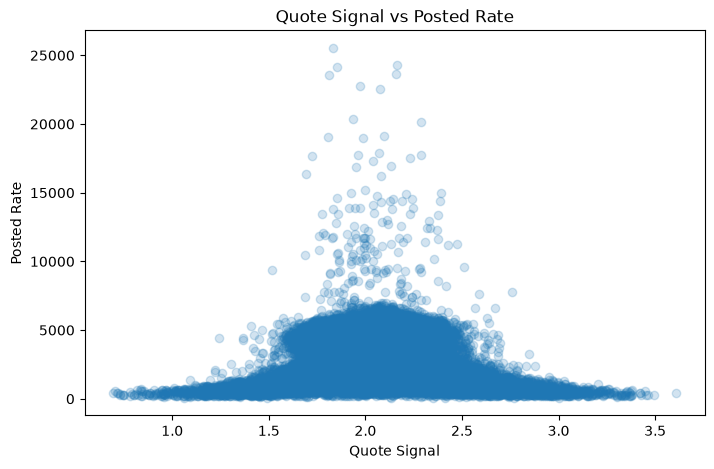

In [37]:
plt.figure(figsize=(8, 5))
plt.scatter(df["quote_signal"], df["posted_rate"], alpha=0.2)
plt.xlabel("Quote Signal")
plt.ylabel("Posted Rate")
plt.title("Quote Signal vs Posted Rate")
plt.show()

In [38]:
quote_bins = pd.qcut(df["quote_signal"], q=10, duplicates="drop")

quote_summary = df.groupby(quote_bins, observed=True)["posted_rate"].agg(
    count="count",
    mean="mean",
    median="median",
    min="min",
    max="max"
)

quote_summary

,count,mean,median,min,max
quote_signal,,,,,
"(0.691, 1.735]",4800,1473.648881,1038.495,59.68,17688.63
"(1.735, 1.851]",4801,2598.360702,2304.070,167.63,25533.00
"(1.851, 1.928]",4799,2679.470338,2430.050,171.28,24140.21
"(1.928, 1.994]",4800,2640.319573,2297.865,218.86,22755.66
"(1.994, 2.056]",4803,2639.470679,2297.590,228.14,17333.65
"(2.056, 2.118]",4797,2635.321910,2270.130,212.76,22534.65
"(2.118, 2.185]",4800,2665.780252,2353.040,82.38,24294.98
"(2.185, 2.266]",4800,2674.993746,2401.185,218.90,17514.11
"(2.266, 2.403]",4800,2469.526812,2051.335,67.80,20132.37


### Insight — Non-Linear Relationship with Posted Rate

Although the Pearson correlation between `quote_signal` and `posted_rate`
is very weak (-0.040), a decile-based analysis reveals a non-linear
relationship.

The average `posted_rate` increases substantially from the lowest
`quote_signal` range and remains relatively elevated through the middle
ranges. It then decreases again in the highest `quote_signal` range.

This indicates that a near-zero Pearson correlation does not imply an
absence of predictive signal. The relationship appears to be non-linear
and should therefore be evaluated using models or analysis capable of
capturing non-linear patterns.

This analysis does not by itself establish data leakage. The temporal
availability and definition of `quote_signal` must be investigated
separately.

In [39]:
(df["posted_rate"] <= 0).sum()

np.int64(0)

In [40]:
Q1_rate = df["posted_rate"].quantile(0.25)
Q3_rate = df["posted_rate"].quantile(0.75)

IQR_rate = Q3_rate - Q1_rate

Q1_rate, Q3_rate, IQR_rate

(np.float64(1251.5549999999998), np.float64(3330.75), np.float64(2079.195))

In [41]:
lower_rate = Q1_rate - 1.5 * IQR_rate
upper_rate = Q3_rate + 1.5 * IQR_rate

lower_rate, upper_rate

(np.float64(-1867.2375000000006), np.float64(6449.5425000000005))

In [42]:
rate_outliers = df[
    (df["posted_rate"] < lower_rate) |
    (df["posted_rate"] > upper_rate)
]

len(rate_outliers)

260

In [43]:
rate_low = (df["posted_rate"] < lower_rate).sum()
rate_high = (df["posted_rate"] > upper_rate).sum()

rate_low, rate_high

(np.int64(0), np.int64(260))

In [44]:
high_rate_outliers = df.loc[
    df["posted_rate"] > upper_rate,
    "posted_rate"
]

high_rate_outliers.describe()

count      260.000000
mean      9940.301231
std       4005.161582
min       6450.500000
25%       6689.960000
50%       8612.130000
75%      11713.742500
max      25533.000000
Name: posted_rate, dtype: float64

### Insight — Posted Rate Quality

The target variable `posted_rate` contains no missing, zero, or negative
values.

An IQR-based analysis identified 260 high statistical outliers, representing
approximately 0.54% of the dataset. No low outliers were detected because
the lower IQR bound is negative while all observed rates are positive.

The high outliers range from 6,450.50 to 25,533, with a median of 8,612.13.
This indicates a relatively small but substantial upper tail in the target
distribution.

Because `posted_rate` is the prediction target, these observations will not
be removed solely based on the IQR rule. Their relationship with explanatory
features such as distance, weight, equipment, and market conditions should
be investigated before deciding whether any special treatment is necessary.

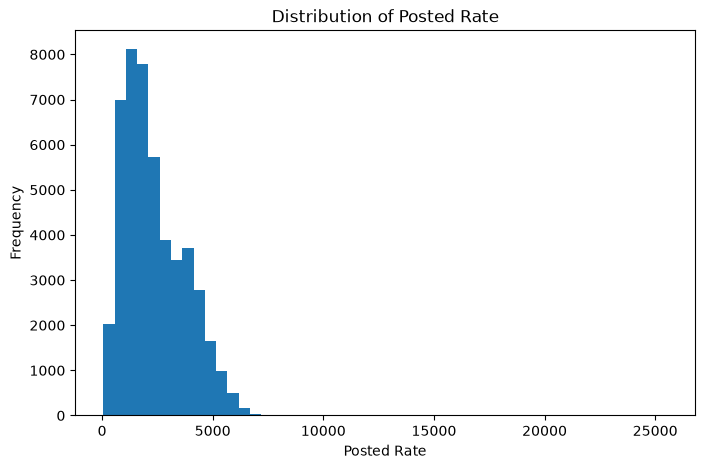

In [45]:
plt.figure(figsize=(8, 5))

plt.hist(df["posted_rate"], bins=50)

plt.xlabel("Posted Rate")
plt.ylabel("Frequency")
plt.title("Distribution of Posted Rate")

plt.show()

In [46]:
df[[
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "distance"
]].describe().T

,count,mean,std,min,25%,50%,75%,max
pickup_lat,48000.0,35.647545,4.315285,28.35765,31.98691,35.29479,39.41104,44.30296
pickup_lon,48000.0,-90.928964,13.482431,-121.69849,-98.40059,-88.08915,-83.28506,-69.50000
delivery_lat,48000.0,35.641175,4.317199,28.35765,31.98691,35.29479,39.41104,44.30296
delivery_lon,48000.0,-90.857310,13.476589,-121.69849,-98.40059,-87.52871,-83.28506,-69.50000
distance,48000.0,1135.856654,728.564416,70.00000,550.40000,953.30000,1645.52500,3439.80000


### Insight — Geographic and Distance Features

The geographic coordinate and `distance` features contain no missing values.

The latitude values range from approximately 28.36 to 44.30, while longitude
values range from approximately -121.70 to -69.50, which is consistent with
the geographic coverage of the dataset.

The `distance` feature ranges from 70 to 3,439.8, with no zero or negative
distances observed. No obvious data-quality issues were identified from the
initial range checks.

These features will be retained for further exploratory and predictive
analysis.

In [47]:
df[["distance", "posted_rate"]].corr()

,distance,posted_rate
distance,1.000000,0.908519
posted_rate,0.908519,1.000000


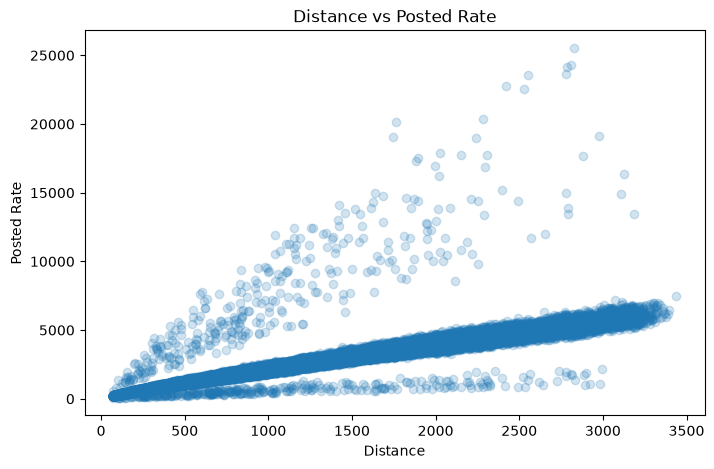

In [48]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["distance"],
    df["posted_rate"],
    alpha=0.2
)

plt.xlabel("Distance")
plt.ylabel("Posted Rate")
plt.title("Distance vs Posted Rate")

plt.show()

### Insight — Distance vs Posted Rate

`distance` has a strong positive linear relationship with `posted_rate`
(correlation = 0.909). Most observations follow a clear upward linear
pattern, making distance a strong predictive feature.

In [49]:
df[["weight", "posted_rate"]].corr()

,weight,posted_rate
weight,1.00000,0.03484
posted_rate,0.03484,1.00000


### Insight — Weight vs Posted Rate

`weight` has a very weak positive linear relationship with `posted_rate`
(correlation = 0.035), suggesting that weight alone provides limited linear
predictive information about the target.

In [50]:
df[["market_index", "posted_rate"]].corr()

,market_index,posted_rate
market_index,1.000000,0.034165
posted_rate,0.034165,1.000000


### Insight — Market Index vs Posted Rate

`market_index` has a very weak positive linear relationship with `posted_rate`
(correlation = 0.034), indicating limited linear predictive information on
its own.

In [51]:
df.groupby("equipment")["posted_rate"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
equipment,,,
Dry Van,27202,2271.548686,1953.035
Flatbed,8753,2445.087223,2076.810
Reefer,12045,2553.636939,2196.670


### Insight — Equipment vs Posted Rate

Posted rates vary across equipment types. Reefer loads have the highest
mean and median rates, while Dry Van loads have the lowest. This suggests
that equipment type provides useful categorical information for the model.

In [52]:
pickup_rate = df.groupby("pickup")["posted_rate"].agg(
    ["count", "mean", "median"]
)

pickup_rate.sort_values("mean", ascending=False).head(10)

,count,mean,median
pickup,,,
San Francisco,453,4071.207108,4301.810
Fresno,827,3878.910000,4160.280
Reno,642,3765.391199,3836.925
Phoenix,1121,3764.774764,3935.620
Los Angeles,945,3729.638392,3996.610
Bakersfield,1193,3519.365448,3804.880
Tucson,944,3310.996271,3535.995
Las Vegas,277,3292.821913,3633.060
Salt Lake City,394,3144.764112,3316.265


In [53]:
pickup_rate.sort_values("mean").head(10)

,count,mean,median
pickup,,,
Chattanooga,745,1722.937087,1444.580
Memphis,852,1753.727031,1555.270
Nashville,1124,1761.969226,1435.715
Indianapolis,539,1763.485065,1478.960
Cincinnati,1080,1775.167185,1436.255
Atlanta,1029,1788.589504,1411.050
Louisville,344,1792.739273,1543.555
Dayton,543,1814.620755,1541.540
Lexington,1209,1824.140273,1374.590


### Insight — Pickup Location vs Posted Rate

Posted rates vary substantially across pickup locations, with noticeable
differences between higher- and lower-priced origins. Pickup location is
therefore a potentially useful categorical feature for the model.

In [54]:
delivery_rate = df.groupby("delivery")["posted_rate"].agg(
    ["count", "mean", "median"]
)

delivery_rate.sort_values("mean", ascending=False).head(10)

,count,mean,median
delivery,,,
San Francisco,467,4064.472998,4356.600
Fresno,763,3865.377156,4140.170
Phoenix,1090,3751.473110,3921.980
Los Angeles,955,3742.250932,4046.090
Reno,653,3679.871639,3783.880
Bakersfield,1156,3532.198893,3742.535
Las Vegas,292,3428.375274,3707.765
Tucson,997,3363.189789,3591.790
Salt Lake City,406,3164.350788,3316.060


### Insight — Delivery Location vs Posted Rate

Posted rates vary substantially across delivery locations, with higher
average rates concentrated in some destinations. Delivery location is
therefore a potentially useful categorical feature.

In [55]:
delivery_rate.sort_values("mean").head(10)

,count,mean,median
delivery,,,
Cincinnati,1084,1743.254972,1401.650
Chattanooga,708,1764.637274,1487.945
Milwaukee,859,1776.723958,1537.190
Nashville,1064,1777.244380,1512.990
Louisville,367,1781.018474,1493.030
Indianapolis,553,1786.063797,1546.100
Atlanta,1096,1796.178449,1475.730
St. Louis,344,1796.766047,1610.000
Birmingham,318,1818.255660,1592.400


### Insight — Delivery Location vs Posted Rate

Posted rates vary substantially across delivery locations, indicating that
destination location provides useful information for predicting freight
rates.

In [56]:
route = df["pickup"] + " → " + df["delivery"]

In [57]:
route.value_counts().head(10)

Columbia → Oklahoma City     39
Phoenix → Shreveport         39
Lexington → Atlanta          39
Fort Wayne → Philadelphia    38
Shreveport → Hartford        37
Lexington → Cincinnati       37
Fort Wayne → Hartford        37
Richmond → Phoenix           37
Richmond → Oklahoma City     37
Lexington → Kansas City      37
Name: count, dtype: int64

### Insight — Route Frequency

The dataset contains many distinct pickup-to-delivery routes, with the most
frequent individual routes appearing only around 39 times. This indicates
that route-level patterns are highly distributed across the dataset.

In [58]:
route_rate = df.assign(
    route=route
).groupby("route")["posted_rate"].agg(
    ["count", "mean", "median"]
)

In [59]:
route_rate[route_rate["count"] >= 20].sort_values(
    "mean", ascending=False
).head(10)

,count,mean,median
route,,,
Bakersfield → Hartford,35,5998.482286,5402.590
Charleston → Phoenix,20,5983.060500,5164.070
Albany → Los Angeles,20,5968.424500,5958.745
Albany → Phoenix,21,5794.950952,5789.470
Phoenix → Albany,21,5738.797143,5697.120
Phoenix → Syracuse,28,5718.156786,4901.345
Los Angeles → Albany,21,5700.440000,5653.260
Hartford → Phoenix,26,5672.923462,5673.345
Phoenix → Hartford,23,5658.245217,5547.790


### Insight — Route vs Posted Rate

Route-level analysis shows substantial differences in average posted rates
across frequently observed routes. This suggests that the combination of
pickup and delivery locations contains predictive information beyond either
location individually.

In [60]:
date_temp = pd.to_datetime(df["date"])

date_temp.min(), date_temp.max()

(Timestamp('2025-01-01 00:00:00'), Timestamp('2025-10-31 00:00:00'))

In [61]:
monthly_rate = df.assign(
    date=date_temp
).groupby(
    date_temp.dt.to_period("M")
)["posted_rate"].agg(
    ["count", "mean", "median"]
)

monthly_rate

,count,mean,median
date,,,
2025-01,4918,2255.967048,1915.200
2025-02,4337,2273.804801,1994.250
2025-03,5036,2372.268092,2022.920
2025-04,4819,2372.162308,2044.240
2025-05,4913,2421.776342,2065.510
2025-06,4783,2497.030115,2120.220
2025-07,4912,2415.162030,2059.145
2025-08,4759,2338.407661,2015.730
2025-09,4670,2406.374013,2057.130


### Insight — Monthly Rate Trend

Posted rates show moderate variation across the months, with the highest
average observed in June (≈2,497) and the lowest in January (≈2,256).
This indicates that time may provide some predictive information, although
the monthly differences are relatively moderate.

In [62]:
weekday_rate = df.assign(
    date=date_temp
).groupby(
    date_temp.dt.day_name()
)["posted_rate"].agg(
    ["count", "mean", "median"]
)

weekday_rate

,count,mean,median
date,,,
Friday,6975,2376.849855,2029.100
Monday,6769,2349.308676,2015.110
Saturday,6770,2373.714334,2044.845
Sunday,6808,2335.073176,2022.035
Thursday,6934,2403.265599,2037.650
Tuesday,6737,2372.890626,2029.630
Wednesday,7007,2405.086706,2036.580


### Insight — Day of Week vs Posted Rate

Posted rates show modest variation across weekdays, with Wednesday having
the highest average and Sunday the lowest. The differences are relatively
small, suggesting that day-of-week may provide limited but potentially
useful temporal information.

In [63]:
numeric_cols = [
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "posted_rate"
]

df[numeric_cols].corr()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
pickup_lat,1.000000,0.559208,-0.008283,-0.006143,-0.077742,0.001898,-0.001735,-0.004181,-0.090873
pickup_lon,0.559208,1.000000,-0.008609,-0.012231,-0.273411,0.006603,0.001432,0.013659,-0.255058
delivery_lat,-0.008283,-0.008609,1.000000,0.557083,-0.080646,-0.004243,-0.002587,-0.002708,-0.091970
delivery_lon,-0.006143,-0.012231,0.557083,1.000000,-0.275657,-0.001144,-0.008487,0.011437,-0.257086
distance,-0.077742,-0.273411,-0.080646,-0.275657,1.000000,0.002544,-0.002181,-0.057244,0.908519
weight,0.001898,0.006603,-0.004243,-0.001144,0.002544,1.000000,-0.001331,0.008159,0.034840
market_index,-0.001735,0.001432,-0.002587,-0.008487,-0.002181,-0.001331,1.000000,-0.067827,0.034165
quote_signal,-0.004181,0.013659,-0.002708,0.011437,-0.057244,0.008159,-0.067827,1.000000,-0.039858
posted_rate,-0.090873,-0.255058,-0.091970,-0.257086,0.908519,0.034840,0.034165,-0.039858,1.000000


### Insight — Numerical Feature Relationships

The strongest numerical relationship is between `distance` and `posted_rate`
(correlation = 0.909).

Most other feature pairs show weak linear correlations, suggesting limited
multicollinearity among the main numerical predictors.

### Insight — Quote Signal and Leakage Consideration

The dataset does not provide a definition of how `quote_signal` was
generated or when it became available.

Although its linear correlation with `posted_rate` is weak, its observed
non-linear relationship means that correlation alone cannot rule out
information leakage.

The feature will therefore be retained for now, with its availability
treated as a modeling consideration during feature selection and validation.

*******************************************************************************************************

# EDA Summary & Modeling Considerations

### Key Findings

- `weight` contains 300 missing values and invalid negative values.
- `market_index` contains 374 missing values.
- `distance` has the strongest linear relationship with `posted_rate`
  (correlation ≈ 0.909).
- `equipment`, `pickup`, `delivery`, and route combinations show meaningful
  differences in average posted rates.
- `posted_rate` has a right-skewed distribution with a small upper tail;
  target outliers will be retained.
- `quote_signal` shows a non-linear relationship with the target, while its
  generation process is not documented.
- Monthly and weekly rate variations are present but relatively moderate.
- No major multicollinearity was observed among the main numerical features.

### Modeling Considerations

- Handle missing and invalid `weight` values during preprocessing.
- Impute missing `market_index` values without introducing target leakage.
- Preserve valid target observations, including high-rate observations.
- Treat `pickup`, `delivery`, `equipment`, and route information carefully
  due to categorical cardinality.
- Investigate suitable feature engineering for geographic and temporal data.
- Evaluate `quote_signal` carefully during feature selection and validation
  because its generation process is undocumented.